# COMPAS: solución reconciliada de sesgo histórico

Copia de resolución de [2.2_compas_historikoa_soluzioa.ipynb](../../materialak/Alborapenak/2.2_compas_historikoa_soluzioa.ipynb); el material original se conserva.

## Resultado principal

Con el umbral del material, **score >= 7**, los FPR observados son **22,8% (African-American) y 8,3% (Caucasian)**; los FNR son **49,2% y 72,0%**. Estos valores sustituyen la atribución errónea de ~44/23% FPR y ~28/48% FNR al umbral 7. El contraste separado con umbral 5 cambia los resultados, pero no reproduce toda la metodología histórica de ProPublica.

Las cifras describen esta población filtrada y una etiqueta registrada a dos años. **No establecen causas del sesgo ni un veredicto sobre legalidad o utilización judicial.**

## Contexto y método

Fuente: [repositorio original ProPublica](https://github.com/propublica/compas-analysis), archivo `compas-scores-two-years.csv`, commit `c062fbb5fa84f6c99d82f432c46b405f3a0ca5ec`; SHA-256 `c451db85908b2f7fef1d83203bedf6b71ecda0d5af468d82ae62178f91d0cc7d`.

Se mantienen los filtros del material: ventana de screening/arresto inclusiva [-30,30], `is_recid != -1`, `c_charge_degree != O`, `score_text != N/A`; luego solo etiquetas de grupo `African-American` y `Caucasian`. Las categorías se conservan como aparecen en la fuente, sin inferir identidades.

### Supuestos clave

- Unidad: un registro de la fuente. No se recoge una cohorte nueva ni se entrena un predictor: se evalúa el score histórico existente.
- Positivo real: `two_year_recid == 1`, una etiqueta observada del dataset; no una medición exhaustiva de conducta delictiva ni una propiedad inherente de un grupo.
- Positivo predicho: `decile_score >= 7` en el resultado principal. `>=5` es un análisis de sensibilidad separado sobre exactamente los mismos registros.
- Los errores se calculan contra esa etiqueta; sus denominadores difieren de los de PPV y accuracy.
- El decil es ordinal, **no** una probabilidad como `score/10`. La similitud visual de tasas por score no demuestra calibración probabilística ni equivalencia estadística.
- El CSV con registros individuales se mantiene fuera del repositorio, con permisos privados. No se muestran ejemplos, nombres, IDs, fechas personales ni predicciones individuales. Solo se guardan agregados.

## Preparación

Ejecutar desde esta carpeta con el entorno descrito en [README.md](README.md). El helper valida el hash fijo antes de cargar únicamente las siete columnas necesarias. Si falta la caché externa, descarga por HTTPS el archivo fijado al commit; ninguna copia nueva del CSV original entra en Git.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown, Image
from compas_reconciliar import run_analysis, prepare_data, OUTPUT, GROUPS

pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 150)
metrics, scores, provenance = run_analysis()
print('Fuente SHA-256:', provenance['sha256'])
print('Versiones:', provenance['versions'])

Fuente SHA-256: c451db85908b2f7fef1d83203bedf6b71ecda0d5af468d82ae62178f91d0cc7d
Versiones: {'numpy': '2.5.3', 'pandas': '3.0.6', 'matplotlib': '3.11.2', 'nbformat': '5.11.1', 'nbclient': '0.11.0', 'ipykernel': '7.4.0'}


## Datos y población

Los filtros se aplican secuencialmente. El resultado de todos ellos incluye 6.172 registros; restringir a los dos grupos produce 5.278 (3.175 y 2.103). Los porcentajes principales no tienen como denominador los 7.214 registros de entrada.

In [2]:
display(pd.DataFrame(provenance['filter_counts']))
display(metrics.loc[metrics.threshold.eq(7), ['group', 'n', 'negatives', 'positives']].reset_index(drop=True))

,step,n
0,raw source,7214
1,days_b_screening_arrest between -30 and 30 inc...,6172
2,is_recid != -1,6172
3,c_charge_degree != O,6172
4,score_text != N/A,6172
5,"race in African-American, Caucasian",5278


,group,n,negatives,positives
0,African-American,3175,1514,1661
1,Caucasian,2103,1281,822


## Resultados: umbral 7

Filas reales y columnas predichas: `[[TN, FP], [FN, TP]]`.

- FPR = FP/(FP+TN): positivos predichos entre etiquetas reales 0.
- FNR = FN/(FN+TP): negativos predichos entre etiquetas reales 1.
- TPR = TP/(TP+FN) = 1-FNR.
- Base rate = (TP+FN)/n: proporción de etiquetas reales 1 en el grupo.
- PPV = TP/(TP+FP): proporción de etiquetas 1 entre positivos predichos.
- Accuracy = (TN+TP)/n. Un valor agregado parecido no exige errores iguales por grupo.

In [3]:
def readable_table(threshold):
    columns = ['group', 'n', 'TN', 'FP', 'FN', 'TP', 'base_rate', 'FPR', 'FNR', 'TPR', 'PPV', 'accuracy']
    table = metrics.loc[metrics.threshold.eq(threshold), columns].copy()
    for column in ['base_rate', 'FPR', 'FNR', 'TPR', 'PPV', 'accuracy']:
        table[column] = table[column].map(lambda v: f'{v:.2%}')
    return table.reset_index(drop=True)

display(readable_table(7))
by_group = metrics[metrics.threshold.eq(7)].set_index('group')
a, c = (by_group.loc[g] for g in GROUPS)
display(Markdown(
    f"**Umbral 7:** FPR African-American {a.FPR:.2%} frente a Caucasian {c.FPR:.2%}; "
    f"ratio observado {a.FPR/c.FPR:.2f} y diferencia {(a.FPR-c.FPR)*100:.2f} puntos porcentuales. "
    f"FNR {a.FNR:.2%} frente a {c.FNR:.2%}. Las tasas base son {a.base_rate:.2%} y {c.base_rate:.2%}. "
    "Son diferencias descriptivas de esta muestra, no efectos causales ni un test de equivalencia."
))

,group,n,TN,FP,FN,TP,base_rate,FPR,FNR,TPR,PPV,accuracy
0,African-American,3175,1169,345,818,843,52.31%,22.79%,49.25%,50.75%,70.96%,63.37%
1,Caucasian,2103,1175,106,592,230,39.09%,8.27%,72.02%,27.98%,68.45%,66.81%


**Umbral 7:** FPR African-American 22.79% frente a Caucasian 8.27%; ratio observado 2.75 y diferencia 14.51 puntos porcentuales. FNR 49.25% frente a 72.02%. Las tasas base son 52.31% y 39.09%. Son diferencias descriptivas de esta muestra, no efectos causales ni un test de equivalencia.

### Contraste separado: umbral 5

Cambiar de `>=7` a `>=5` aumenta los positivos predichos: puede subir FPR y bajar FNR. En la población seleccionada, `>=5` coincide con `score_text != Low` (Medium + High), verificado en código.

El texto original (~44/23% FPR, ~28/48% FNR) **no coincide con el umbral 7**. El umbral 5 aproxima algunos porcentajes, pero aquí resulta **42,34/22,01% FPR y 28,48/49,64% FNR**. No se afirma una reproducción exacta de la publicación: esta resolución usa el CSV de dos años y los filtros del material, sin reconstruir su análisis de supervivencia y sus tablas históricas. Cambiar solo el umbral no reconcilia automáticamente cohortes y métodos distintos.

,group,n,TN,FP,FN,TP,base_rate,FPR,FNR,TPR,PPV,accuracy
0,African-American,3175,873,641,473,1188,52.31%,42.34%,28.48%,71.52%,64.95%,64.91%
1,Caucasian,2103,999,282,408,414,39.09%,22.01%,49.64%,50.36%,59.48%,67.19%


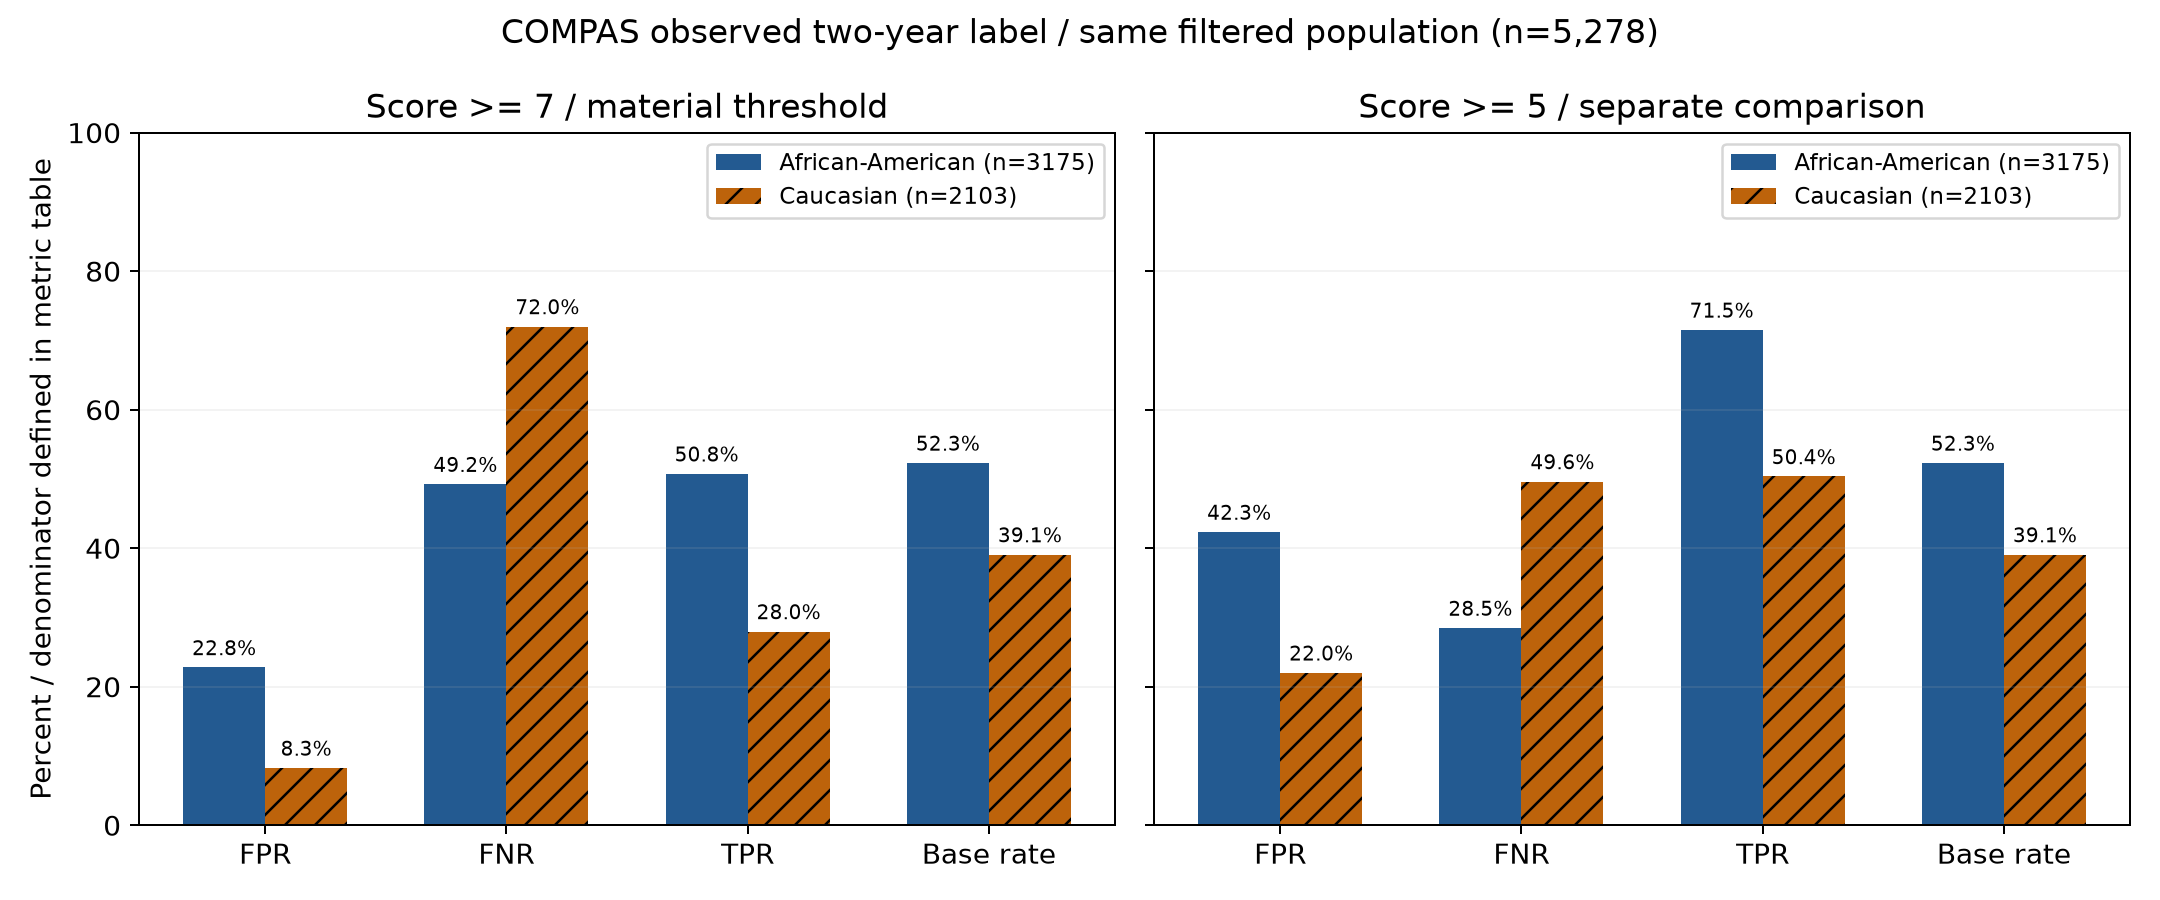

In [4]:
display(readable_table(5))
display(Image(filename=str(OUTPUT / 'tasas_por_umbral.png')))

### Tasas observadas por score

Se agrupan los 5.278 registros por grupo y decil. La tabla conserva numerador, denominador, tasa y un intervalo Wilson binomial del 95%. Los intervalos son orientativos: no modelan sesgos del proceso de registro ni prueban equivalencia entre grupos; solaparse no es un test de igualdad.

Esta figura responde «¿qué proporción tiene etiqueta 1 en cada decil?»; no «¿está calibrada una probabilidad de 70%?». No se dibuja una diagonal `y=score/10` porque esa conversión de decil a probabilidad no está justificada.

,group,score,positives,n,observed_rate,lower_95,upper_95
0,African-American,1,85,365,0.2329,0.1924,0.2789
1,African-American,2,105,346,0.3035,0.2574,0.3539
2,African-American,3,125,298,0.4195,0.3648,0.4762
3,African-American,4,158,337,0.4688,0.4162,0.5222
4,African-American,5,158,323,0.4892,0.4351,0.5435
5,African-American,6,187,318,0.5881,0.5332,0.6408
6,African-American,7,209,343,0.6093,0.5568,0.6595
7,African-American,8,215,301,0.7143,0.6608,0.7624
8,African-American,9,229,317,0.7224,0.6707,0.7688
9,African-American,10,190,227,0.8370,0.7834,0.8794


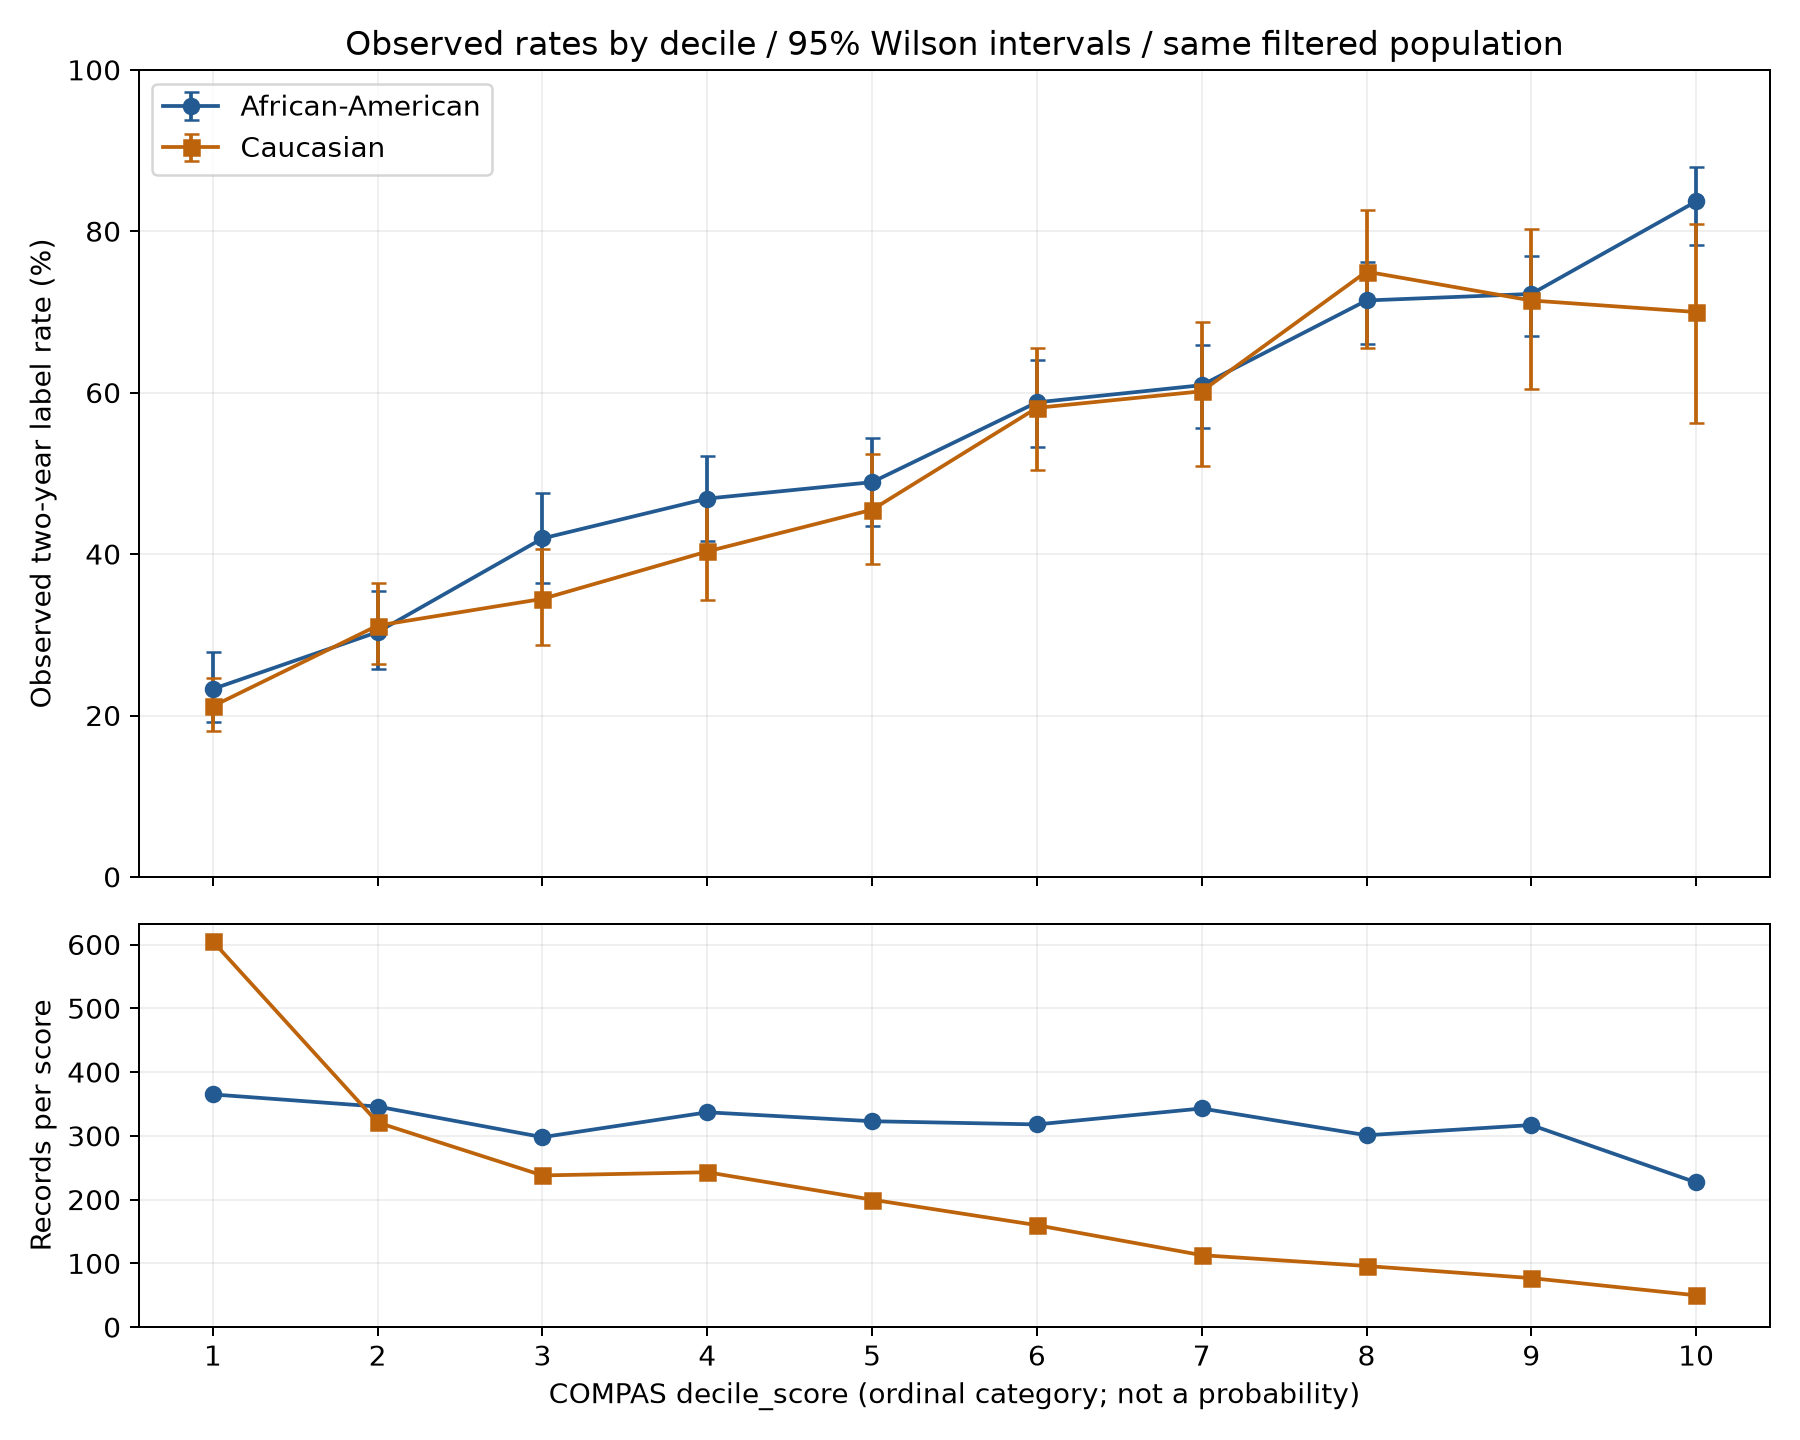

In [5]:
display(scores.round({'observed_rate': 4, 'lower_95': 4, 'upper_95': 4}))
display(Image(filename=str(OUTPUT / 'tasas_por_score.png')))

## Comprobaciones

Se vuelven a contar las matrices con una operación independiente (`crosstab`), se verifican los denominadores, la suma por decil y la dirección del cambio al bajar el umbral. Los datos individuales quedan únicamente en memoria del kernel y fuera de sus outputs.

In [6]:
clean, _ = prepare_data()
for row in metrics.itertuples():
    group_data = clean[clean.race.eq(row.group)]
    matrix = pd.crosstab(group_data.two_year_recid, group_data.decile_score.ge(row.threshold)).reindex(
        index=[0, 1], columns=[False, True], fill_value=0)
    assert matrix.to_numpy().tolist() == [[row.TN, row.FP], [row.FN, row.TP]]
    assert row.TN + row.FP == row.negatives
    assert row.TP + row.FN == row.positives
    assert row.FPR == row.FP / row.negatives
    assert row.FNR == row.FN / row.positives
    assert abs(row.TPR + row.FNR - 1) < 1e-12
    per_score = scores[scores.group.eq(row.group)]
    assert int(per_score.n.sum()) == row.n
    assert int(per_score.positives.sum()) == row.positives
for group in GROUPS:
    m = metrics[metrics.group.eq(group)].set_index('threshold')
    assert m.loc[5, 'FPR'] >= m.loc[7, 'FPR']
    assert m.loc[5, 'FNR'] <= m.loc[7, 'FNR']
    assert m.loc[5, 'base_rate'] == m.loc[7, 'base_rate']
del clean, group_data
print('Verificado: cuatro matrices, denominadores, veinte agregados por score y contraste de umbrales.')

Verificado: cuatro matrices, denominadores, veinte agregados por score y contraste de umbrales.


## Respuestas reconciliadas a las preguntas del material

**1. ¿Puede ser «preciso» y presentar disparidades a la vez?** Sí, un agregado como accuracy o PPV no impone igualdad de FPR/FNR. En este cálculo ambas clases de métricas se muestran con sus denominadores; las disparidades de error están medidas, pero no se ha demostrado calibración probabilística ni se ha verificado un teorema a partir del parecido de dos líneas. Las diferencias de tasas base son observaciones, no prueba de una causa histórica, biológica o inherente.

**2. ¿Debe utilizarlo un juez? ¿Con qué garantías?** Esta práctica no establece utilidad judicial. Antes de valorar un uso real harían falta evaluación de finalidad y daños, validación independiente en su contexto, calidad y significado de las etiquetas, evaluación de errores por grupo y mecanismos efectivos de explicación y revisión humana. Son criterios de discusión y diseño, no una autorización ni una lista exhaustiva de requisitos legales. No se deduce una regla universal como «ratio <1,3» de estas cuentas.

**3. ¿Es legal en la UE?** El CSV y estas tasas no permiten determinar la legalidad de un sistema o decidir su categoría regulatoria. Esa evaluación exige conocer finalidad, diseño, contexto, papel humano, base del tratamiento de datos y normas vigentes aplicables. No se reproducen como hechos verificados las afirmaciones del original sobre multas, prohibición universal, marcado CE o fechas de aplicación. La pregunta jurídica queda como análisis específico separado, no como una conclusión estadística.

## Límites y conclusión

Se reconcilian **los outputs estadísticos del ejercicio con su umbral 7** y se conserva un contraste explícito de umbral 5. La etiqueta histórica no mide todo el fenómeno; la selección y el proceso de registro pueden afectar resultados. No hay intervención, identificación causal, validación externa, test de equivalencia, selección de umbral óptimo ni entrenamiento de modelo. Los intervalos por score no corrigen sesgos del dato. Los dos grupos y la población histórica seleccionada no representan todas las poblaciones ni permiten inferir atributos individuales.

Salidas publicables en esta entrega: dos tablas agregadas, metadatos de fuente/versión, dos gráficos y este notebook ejecutado. La fuente individual queda en caché privada externa. Los cambios son locales; no hay commit ni publicación.